# 01 — Data Quality and Cleaning

**Spotify Content Performance Analytics** — Phase 2 data foundation.

This notebook:
1. loads the raw extract through `src/` (with SHA-256 validation),
2. reproduces the data-quality audit,
3. explains the cleaning decisions and derived fields,
4. shows the genre-availability bias analysis,
5. shows the popularity-distribution / sampling-frame limitations,
6. compares primary vs. sensitivity-dataset KPIs,
7. checks output row counts and score bounds for the processed dataset
   (Parquet + DuckDB).

**Scope reminder:** this is observational catalog data of unknown sampling
frame and unknown collection time. No causal claims are made. Every
percentage/share below describes "tracks in this dataset," not Spotify's
catalog generally. See the root `README.md` for the full measurement-caveat
discussion.

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import matplotlib.pyplot as plt

from src.load_data import load_raw, EXPECTED_SHA256, DEFAULT_RAW_PATH, compute_sha256
from src.clean_data import build_primary_dataset, build_sensitivity_dataset, POPULARITY_TIER_BOUNDS
from src.build_database import build_processed_datasets, write_processed_parquet, build_database, PRIMARY_TABLE, SENSITIVITY_TABLE
from src.metrics import kpi_summary
from src import quality_audit as qa

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

## 1. Load raw data and verify the source hash

The loader validates the file's SHA-256 before parsing a single row, and
skips the course-specific row-2 type-declaration row.

In [2]:
actual_hash = compute_sha256(DEFAULT_RAW_PATH)
print("Expected SHA-256:", EXPECTED_SHA256)
print("Actual SHA-256:  ", actual_hash)
assert actual_hash == EXPECTED_SHA256, "Raw file hash mismatch!"

raw = load_raw()
print(f"\nLoaded {len(raw):,} rows x {raw.shape[1]} columns")
raw.head(3)

Expected SHA-256: 4045adda473d6cd4fde6f3a11253faf37d7ee26fd122bcfd5c8a6c1fc5441974
Actual SHA-256:   4045adda473d6cd4fde6f3a11253faf37d7ee26fd122bcfd5c8a6c1fc5441974



Loaded 277,938 rows x 34 columns


,track,artist_1,artist_1_pop,artist_2,artist_2_pop,artist_3,artist_3_pop,artist_1_genre_1,artist_1_genre_2,artist_1_genre_3,artist_2_genre_1,artist_2_genre_2,artist_2_genre_3,artist_3_genre_1,artist_3_genre_2,artist_3_genre_3,release_date,release_decade,danceability,energy,speechiness,acousticness,instrumentalness,liveness,popularity,duration,album_type,popularity_score,key,loudness,valence,tempo,duration_ms,time_signature
0,Way Up (feat. Ava Re),Floduxe,0.09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015.0,2010.0,1moderate,1moderate,0low,0low,0low,2high,0low,2three_to_ten_minutes,single,0,5,-8.815,0.520,128.050,195000,4
1,Fantasy - Felix Jaehn Remix,Alina Baraz Galimatias,0.68,NaN,0.56,NaN,NaN,pop,pop,r&b,NaN,NaN,NaN,NaN,NaN,NaN,2015.0,2010.0,1moderate,2high,0low,0low,0low,1moderate,0low,2three_to_ten_minutes,album,33,4,-6.848,0.250,122.985,194641,4
2,Try Me,DeJ Loaf,0.65,NaN,NaN,NaN,NaN,hip hop,pop,r&b,NaN,NaN,NaN,NaN,NaN,NaN,2014.0,2010.0,1moderate,2high,0low,0low,0low,0low,1moderate,2three_to_ten_minutes,single,52,0,-8.029,0.247,170.044,217573,4


## 2. Data-quality audit (recomputed, not hard-coded)

All numbers below come directly from `src/quality_audit.py` functions run
against the raw DataFrame just loaded — see `reports/data_quality_report.md`
for the full narrative writeup of these same figures.

In [3]:
print("Shape:", qa.basic_shape(raw))
print()
print("Exact full-row duplicates:", qa.exact_duplicate_stats(raw))
print()
print("(track, artist_1) duplicate stats:", qa.track_artist_duplicate_stats(raw))

Shape: {'n_rows': 277938, 'n_columns': 34}



Exact full-row duplicates: {'rows_in_duplicate_groups': 2, 'rows_removed_on_dedup': 1}



(track, artist_1) duplicate stats: {'duplicate_groups': 92, 'rows_in_duplicate_groups': 184, 'max_group_size': 2}


In [4]:
missingness = qa.missingness_report(raw)
missingness.head(15)

,n_missing,pct_missing
artist_2,277938,100.000
artist_3,277938,100.000
artist_3_genre_3,276746,99.571
artist_3_genre_2,276077,99.330
artist_3_genre_1,275393,99.084
artist_2_genre_3,272706,98.118
artist_2_genre_2,269880,97.101
artist_3_pop,268435,96.581
artist_2_genre_1,267330,96.183
artist_2_pop,243160,87.487


In [5]:
print("tempo == 0 count:", qa.tempo_zero_count(raw))
print("release_date == 1899 count:", qa.suspicious_release_date_count(raw))
print()
print("time_signature distribution (documented valid values are {3,4,5,7}):")
print(qa.unusual_time_signature_counts(raw))
print()
print("artist_2 / artist_3 missingness:", qa.artist_2_3_missingness(raw))
print()
print("Primary genre completeness:", qa.primary_genre_completeness(raw))

tempo == 0 count: 90
release_date == 1899 count: 13

time_signature distribution (documented valid values are {3,4,5,7}):
time_signature
0        95
1      3192
3     29582
4    239497
5      5572
Name: count, dtype: int64

artist_2 / artist_3 missingness: {'artist_2_missing_pct': 100.0, 'artist_3_missing_pct': 100.0, 'artist_2_pop_missing_pct': 87.487, 'artist_3_pop_missing_pct': 96.581}

Primary genre completeness: {'n_present': 110387, 'n_missing': 167551, 'pct_present': 39.716}


**Notable finding:** `artist_2` / `artist_3` (artist *name*) are 100%
missing, yet `artist_2_pop` / `artist_3_pop` are populated for a meaningful
share of rows — a numeric popularity value exists for artists this extract
never retained a name for. This is why `artist_2`/`artist_3` are documented
as unusable name fields (see cleaning policy) rather than attempted to be
reconstructed.

In [6]:
print("Album type distribution:")
print(qa.album_type_distribution(raw))
print()
print("Release-decade distribution:")
print(qa.release_decade_distribution(raw))

Album type distribution:
album_type
album          161873
single          92835
compilation     23230
Name: count, dtype: int64

Release-decade distribution:
release_date
1890.0        13
1900.0        10
1910.0        18
1920.0        68
1930.0       123
1940.0        99
1950.0      1349
1960.0      4010
1970.0      6515
1980.0      8244
1990.0     19580
2000.0     40579
2010.0    108480
2020.0     88846
NaN            4
Name: count, dtype: int64


## 3. Popularity-score distribution and sampling-frame caveats

`popularity_score` is Spotify's algorithmic popularity metric at an unknown
collection time. The distribution below shows a large spike at exactly 0
and a sparse lower tail. The extract does not document whether this
reflects score construction, collection choices, or both.

In [7]:
pop_dist = qa.popularity_distribution(raw)
for k, v in pop_dist.items():
    print(f"{k}: {v}")

n_zero: 46868
pct_zero: 16.863
quantiles: {0.0: 0.0, 0.01: 0.0, 0.05: 0.0, 0.1: 0.0, 0.25: 8.0, 0.5: 28.0, 0.75: 44.0, 0.9: 56.0, 0.99: 73.0, 1.0: 100.0}
mean: 27.79663090329498
median: 28.0
skew: 0.20146377786791098


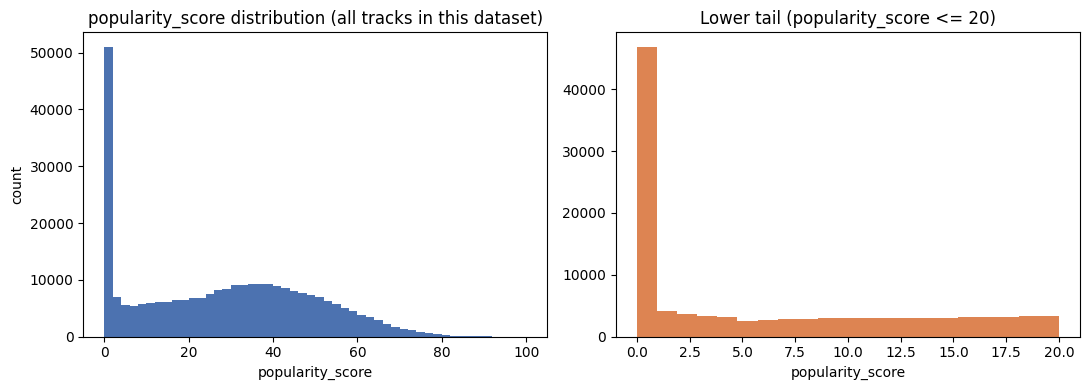

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(raw["popularity_score"].dropna(), bins=50, color="#4C72B0")
axes[0].set_title("popularity_score distribution (all tracks in this dataset)")
axes[0].set_xlabel("popularity_score")
axes[0].set_ylabel("count")

low_tail = raw.loc[raw["popularity_score"] <= 20, "popularity_score"]
axes[1].hist(low_tail, bins=21, color="#DD8452")
axes[1].set_title("Lower tail (popularity_score <= 20)")
axes[1].set_xlabel("popularity_score")

plt.tight_layout()
plt.show()

## 4. Genre-availability bias check

Comparing tracks with a populated `artist_1_genre_1` against tracks without
one, on popularity, artist popularity, and sample size.

In [9]:
genre_bias = qa.genre_availability_bias(raw)
genre_bias

,with_primary_genre,without_primary_genre
n,110387.000000,167551.000000
share_of_dataset,0.397200,0.602800
median_popularity_score,35.000000,25.000000
mean_popularity_score,32.623452,24.616594
mean_artist_1_pop,0.555134,0.374879


**Direction and magnitude:** tracks with an observed primary genre have
meaningfully higher median/mean `popularity_score` and higher mean
`artist_1_pop` than tracks without one (see the table above and
`reports/data_quality_report.md` §15 for the release-decade comparison too).
**Genre availability is not random with respect to popularity in this
dataset.** Every genre-conditioned finding elsewhere in this project is
scoped to "tracks in this dataset with an observed primary genre."

## 5. `popularity_tier` threshold recovery

Rather than inventing a business threshold, we cross-tabulated the raw
categorical `popularity` column against `popularity_score` to see whether it
is a deterministic banding.

In [10]:
tier_check = raw.groupby("popularity")["popularity_score"].agg(["min", "max", "count"])
tier_check

,min,max,count
popularity,,,
0low,0,33,161825
1moderate,34,66,108186
2high,67,100,7927


In [11]:
print("Recovered thresholds used for popularity_tier / is_high_popularity:")
for tier, bounds in POPULARITY_TIER_BOUNDS.items():
    print(f"  {tier}: {bounds}")

Recovered thresholds used for popularity_tier / is_high_popularity:
  low: (0, 33)
  moderate: (34, 66)
  high: (67, 100)


The bounds match the raw `popularity` column exactly (`0low`=0–33,
`1moderate`=34–66, `2high`=67–100) — these are the dataset's own recovered
thresholds, not an analyst-invented cutoff, and are not represented as an
official Spotify definition.

## 6. Build the primary and sensitivity datasets

- **Primary dataset:** exact full-row duplicates removed; `(track,
  artist_1)` repeats retained (no reliable track identifier exists to
  distinguish them from true duplicates, and deduplicating on
  `popularity_score` would select on the outcome variable).
- **Sensitivity dataset:** one row per `(track, artist_1)`, chosen by a
  documented stable sort that never references `popularity_score`.

In [12]:
primary, dedup_stats = build_primary_dataset(raw)
sensitivity = build_sensitivity_dataset(primary)

print("Dedup stats:", dedup_stats)
print(f"Primary dataset:     {len(primary):,} rows")
print(f"Sensitivity dataset: {len(sensitivity):,} rows")
print()
print("Derived / flag columns added:")
print([c for c in primary.columns if c not in raw.columns])

Dedup stats: {'rows_involved_in_duplicate_groups': 2, 'rows_removed': 1, 'row_count_before': 277938, 'row_count_after': 277937}
Primary dataset:     277,937 rows
Sensitivity dataset: 277,846 rows

Derived / flag columns added:
['release_year', 'release_decade_clean', 'track_duration_minutes', 'popularity_tier', 'is_high_popularity', 'has_primary_genre', 'exact_duplicate_flag', 'track_artist_duplicate_flag', 'tempo_quality_flag', 'suspicious_release_date_flag']


In [13]:
print("Exact duplicates remaining in primary (should be 0):", primary["exact_duplicate_flag"].sum())
print("(track, artist_1) repeats remaining in primary:", primary["track_artist_duplicate_flag"].sum())
print("Duplicates remaining in sensitivity (should be 0):",
      sensitivity.duplicated(subset=["track", "artist_1"]).sum())

Exact duplicates remaining in primary (should be 0): 0
(track, artist_1) repeats remaining in primary: 182
Duplicates remaining in sensitivity (should be 0): 0


## 7. Primary vs. sensitivity dataset — KPI comparison

If deduplicating repeats materially changed core KPIs, that would be an
important caveat for every later analysis. It does not, for any metric
except `repeat_track_artist_share` itself (a mechanical consequence of the
sensitivity dataset's definition, not a substantive finding).

In [14]:
p_kpi = kpi_summary(primary)
s_kpi = kpi_summary(sensitivity)

rows = []
for key in p_kpi:
    pv, sv = p_kpi[key], s_kpi[key]
    abs_delta = sv - pv
    rel_delta = (abs_delta / pv * 100) if pv else float("nan")
    rows.append({"metric": key, "primary": pv, "sensitivity": sv,
                 "abs_delta": abs_delta, "rel_delta_pct": rel_delta})

kpi_comparison = pd.DataFrame(rows).set_index("metric")
kpi_comparison

,primary,sensitivity,abs_delta,rel_delta_pct
metric,,,,
track_observation_count,277937.000000,277846.000000,-91.000000,-0.032741
median_popularity_score,28.000000,28.000000,0.000000,0.000000
mean_popularity_score,27.796731,27.798378,0.001647,0.005924
high_popularity_share,0.028521,0.028516,-0.000005,-0.017725
primary_genre_coverage,0.397162,0.397152,-0.000010,-0.002590
median_track_duration_minutes,3.551783,3.551783,0.000000,0.000000
median_artist_popularity,0.470000,0.470000,0.000000,0.000000
repeat_track_artist_share,0.000655,0.000000,-0.000655,-100.000000


**Conclusion:** deltas are trivial for every KPI except
`repeat_track_artist_share`, which is exactly 0% in the sensitivity dataset
by construction (one row per `(track, artist_1)` cannot contain a repeat).
No popularity, genre, duration, or artist-popularity conclusion in this
project would change depending on which dataset was used.

## 8. Build processed outputs and check row counts and score bounds

Write Parquet outputs and build the DuckDB database, then check that row
counts match the in-memory datasets and popularity scores stay in bounds.

In [15]:
write_processed_parquet(primary, sensitivity)

con = build_database(primary, sensitivity)
n_primary_db = con.execute(f"SELECT COUNT(*) FROM {PRIMARY_TABLE}").fetchone()[0]
n_sensitivity_db = con.execute(f"SELECT COUNT(*) FROM {SENSITIVITY_TABLE}").fetchone()[0]
min_pop, max_pop = con.execute(f"SELECT MIN(popularity_score), MAX(popularity_score) FROM {PRIMARY_TABLE}").fetchone()
con.close()

assert n_primary_db == len(primary), "DuckDB primary table row count mismatch!"
assert n_sensitivity_db == len(sensitivity), "DuckDB sensitivity table row count mismatch!"
assert 0 <= min_pop and max_pop <= 100, "Impossible popularity_score value in database!"

print(f"DuckDB {PRIMARY_TABLE}: {n_primary_db:,} rows (matches in-memory: {n_primary_db == len(primary)})")
print(f"DuckDB {SENSITIVITY_TABLE}: {n_sensitivity_db:,} rows (matches in-memory: {n_sensitivity_db == len(sensitivity)})")
print(f"popularity_score range in database: [{min_pop}, {max_pop}]")
print("\nRow-count and score-bound checks passed.")

DuckDB tracks_primary: 277,937 rows (matches in-memory: True)
DuckDB tracks_sensitivity: 277,846 rows (matches in-memory: True)
popularity_score range in database: [0, 100]

Row-count and score-bound checks passed.


## 9. Summary

- Raw extract: 277,938 rows x 34 columns, SHA-256 verified.
- Primary analytical dataset: exact duplicates removed only; `(track,
  artist_1)` repeats retained by policy.
- Sensitivity dataset: one row per `(track, artist_1)`, selected without
  reference to `popularity_score`.
- Genre availability, release-decade mix, and the popularity-score
  zero-spike are all documented as measurement/sampling limitations that
  propagate into every later analysis — see `README.md` and
  `reports/data_quality_report.md`.
- Next: `sql/02_kpi_summary.sql` and `sql/03_segment_analysis.sql`, built
  interactively (see README "SQL Analysis").